# Preparing Tools, Runtime, Hardware and Dataset for Training and Evaluating DL Models

In [3]:
# Dependencies
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

# Understanding, Analysing and Exploring Dataset
- Dataset Format : Training Set , Testing Set

- Data Sample Format : [Image(28*28 pixels),number label]


Number of Images : 60000
Image Dimensions : 28 * 28


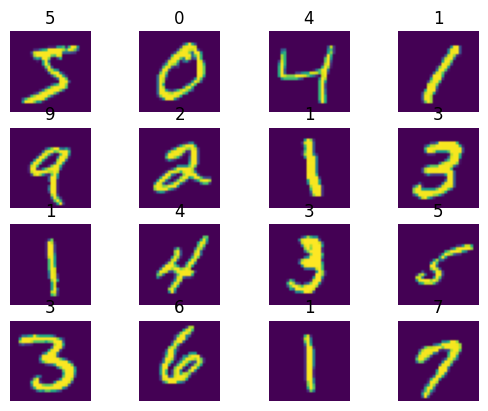

In [4]:
# Exploring Dataset
(x_train, y_train) , (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Number of Images : {len(x_train)}")
print(f"Image Dimensions : {len(x_train[0])} * {len(x_train[0][0])}")

# Seeing Data Samples
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i])
    plt.title(f"{y_train[i]}")
    plt.axis('off')
plt.show()


# Desgining a DL Model : Multi Layer Perceptron

Input Layer
- We treat each pixel as a feature of an image.
- So, 28*28 = 784 pixels = 784 features.
- So, flatten 28*28 image into a 784 * 1 feature(number) vector.

1st Hidden Layer
- Give this feature vector of an image to first layer of neurons of neural network.

Output Layer
- In output, we expect a label from 0-9 corresponding to given image.
- So, we add 10 neurons that represent 0-9 digits, and one of them gives highest output out of all indicating given image is of that digit according to it.
- Output will be an array of 10 floating numbers representing probability that given image could be that digit according to model for all 0-9 digits.

In [5]:
# Sequential Object is the container/box of your neural network, stores and connects layers upon adding or removal autoamtically.
model = Sequential()

# Adding Input Layer - 784 features
model.add(Input(shape=(784,)))

# Adding 1st Hidden Layer to learn basic patterns - Input -> 1st Hidden - 64 neurons
model.add(Dense(256, activation='relu'))

# Adding Output Layer - 10 neurons
model.add(Dense(10, activation='softmax')) # Using softmax - since its 10-class classification

Understanding Learning and Teaching Methods for the Model (Backpropogation)
- Loss Function (Telling model how wrong it was in its prediction in Numbers)
- Optimizer (The type of 'Teacher' with a 'teaching method' to help model learn to predict correctly)

In [6]:
model.compile(
    optimizer = 'Adam', # Teaching or methods to tune weights given to neurons of the model to adjust predictions.
    loss = 'sparse_categorical_crossentropy', # L = -log(y_pred(i)) , where 'i' refers to class that model should have predicted. (Softmax inverse-like)
    metrics = ['accuracy', 'sparse_categorical_accuracy'], # Stats to be tracked during training
)

# Training the DL Model and Hyperparameters
- Preparing and Preprocessing Data for Training :     
  - Formatting
  - Splitting into Training, Validation and Testing
  - Flattening, Handling Missing Values, Scaling or Adjusting Values (like Normalization to certain range etc.)
- Tuning Hyperparameters : Parameters that affect training process of model.
  - Number of Epochs (similar to Training Session)
  - Batch Size (Number of Samples trained on before optimizing weights each time during training)

  and there are plenty more we don't know.

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8655 - loss: 0.4675 - sparse_categorical_accuracy: 0.8655 - val_accuracy: 0.9662 - val_loss: 0.1219 - val_sparse_categorical_accuracy: 0.9662
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9646 - loss: 0.1246 - sparse_categorical_accuracy: 0.9646 - val_accuracy: 0.9717 - val_loss: 0.0968 - val_sparse_categorical_accuracy: 0.9717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9769 - loss: 0.0783 - sparse_categorical_accuracy: 0.9769 - val_accuracy: 0.9772 - val_loss: 0.0793 - val_sparse_categorical_accuracy: 0.9772
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9843 - loss: 0.0558 - sparse_categorical_accuracy: 0.9843 - val_accuracy: 0.9798 - val_loss: 0.0766 - val_sparse_categorical_accuracy: 0.9798
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9887 - loss: 0.0382 - sparse_categorical_accuracy: 0.9887 - val_accuracy: 0.9808 - val_loss: 0.0671 - 

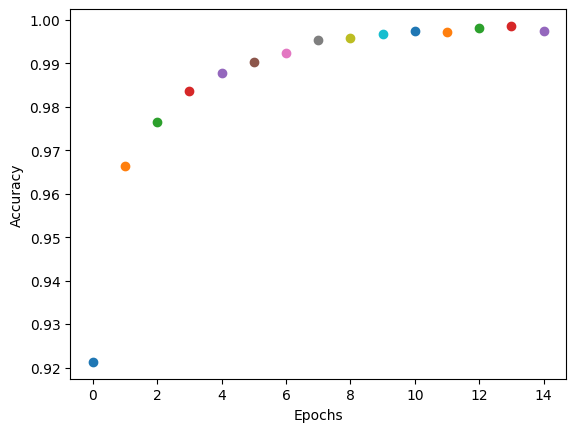

In [7]:
# Flattened Training Dataset of Input Images to feed into model.
x_flat_train = x_train.reshape(len(x_train),784) / 255.0 # Divide every feature value for all data samples by 255 to contain them in 0.0-1.0 range (Normalization)
# Values in 0.0-1.0 help model learn more easily rather than with raw floating values.

# Hyperparameters
Epochs = 15
Batch_Size = 64
Val_Split = 0.1

# Train the model with required hyperparameters
History = model.fit(
    x_flat_train,
    y_train,
    epochs = Epochs,
    batch_size = Batch_Size,
    validation_split = Val_Split
)

# Visualise Training Results (Accuracy vs Number of Epochs)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
for i in range(Epochs) :
  plt.scatter(i,History.history['accuracy'][i])
plt.show()

# Testing and Evaluation of Trained DL Model
- Decide what metrics you want to use and how much and how well it represents model's correctness that you need for your purpose.
- Consider methods used for training before judging the results.
- Decide whether model's performance is enough for your purpose rather than absolute perfection.

In [11]:
# Flattened Testing Dataset of Input Images to feed into model for Evaluation.
x_flat_test = x_test.reshape(len(x_test),784) / 255.0 # Divide every feature value for all data samples by 255 to contain them in 0.0-1.0 range (Normalization)
# Values in 0.0-1.0 help model learn more easily rather than with raw floating values.

# Evaluate the Model.
test_loss, test_acc, test_sparse_cat_acc = model.evaluate(x_flat_test, y_test)

print(f"Test Accuracy : {test_acc:.3f}")
print(f"Test Loss : {test_loss:.3f}")
print(f"Test Sparse Categorical Accuracy: {test_sparse_cat_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0924 - sparse_categorical_accuracy: 0.9768
Test Accuracy : 0.980
Test Loss : 0.082
Test Sparse Categorical Accuracy: 0.980


# Saving and Storing Models for future training and deployment
- Different formats to store model :
  - Full model with architecture, optimizer, loss function and weights. - model.save(filename.h5)
  - Model with only weights (Rest has to be recreated to use in future)
  model.save_weights(filename.h5)
- Future deployment :    
  - model = load_model(filename.h5)

In [12]:
model.save('handwritten_digit_model.h5')